# Parquet Pipeline

In [88]:
%load_ext autoreload
%autoreload 2

import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from convert_calorimeter import write_calohits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


## Combined multi-output conversion (single open per run)

This workflow opens each `edm4hep.root` once per run and produces multiple H5 outputs (truth/particles and reco/tracker_hits) in one pass, reusing preloaded DataFrames to avoid repeated IO.


In [ ]:
# Configurable column selection for H5 outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "cell_id", "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]


In [ ]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup_pilot"
dataset = "ttbar"
version = "v2"

base_root = Path("/pscratch/sd/d/danieltm/ColliderML/simulation")
output_base_dir = Path("./h5_testing/v4")  # unified root like scripts

config = {
    "chunk_size": 10,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup_pilot",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
    },
    "objects": ["tracker_hits", "particles", "tracks"],
    "particles_columns_keep": particles_columns_keep,
    "digihits_columns_keep": digihits_columns_keep,
    "tracks_columns_keep": tracks_columns_keep,
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}


In [ ]:
convert_all(config, chunk_index=0)

## Step-by-step Conversion

Roadmap:

- Convert a small set of edm4hep events to h5

In [129]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "hard_scatter"
dataset = "ttbar"
version = "v1"

base_root = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation")
output_base_dir = Path("./parquet_testing/v1")  # unified root like scripts
input_base_dir = base_root / campaign / dataset / version

# Configurable column selection for outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "cell_id", "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]

calo_columns_keep = [
    "event_id", "detector", "cell_id", "total_energy", "x", "y", "z", "contrib_particle_ids",
    "contrib_energies", "contrib_times"
]


run_dir = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0")

config = {
    "chunk_size": 10,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "hard_scatter",
    "dataset": "ttbar",
    "version": "v1",
    "common": {
        "output_base_dir": base_root,
        "input_base_dir": base_root
    },
    "objects": ["tracks", "tracker_hits", "particles", "calo_hits"],
    "min_tracker_hits": 1,
    "min_calo_hits": 1,
    "h5_output_dir": output_base_dir,
}

### Event lists and loading edm4hep events

In [91]:
from convert_all import *
from convert_all import _compute_paths, _prepare_output_dirs
from convert_digihits import *
from convert_tracks import *
from utils.path_utils import *
from utils.track_utils import *
from utils.driver import *
from utils.config import *


In [125]:
input_base_dir, output_base_dir, dataset_base, dataset_name_dot = _compute_paths(config)
particles_out_dir, trkhits_out_dir, tracks_out_dir, calo_out_dir = _prepare_output_dirs(output_base_dir, dataset_base, output_format="parquet")

In [93]:
particles_frames: list[pd.DataFrame] = []
digihits_frames: list[pd.DataFrame] = []
tracks_frames: list[pd.DataFrame] = []
seen_pairs_tracks: set[tuple[int, int]] = set()
seen_pairs_particles: set[tuple[int, int]] = set()
seen_pairs_hits: set[tuple[int, int]] = set()

In [94]:
run_size = 128
chunk_size = 10
run_dirs = get_run_paths(input_base_dir)
num_runs = len(run_dirs)
num_events = num_runs * run_size

In [95]:
input_base_dir

PosixPath('/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1')

In [96]:
chunk_index = 0

In [97]:
start_event = chunk_index * chunk_size
end_event = min(num_events, start_event + chunk_size) - 1
start_run = start_event // run_size
start_local = start_event % run_size
end_run = end_event // run_size
end_local = end_event % run_size

In [98]:
print(f"Start event: {start_event}, End event: {end_event}, Start run: {start_run}, End run: {end_run}, Start local: {start_local}, End local: {end_local}")

Start event: 0, End event: 9, Start run: 0, End run: 0, Start local: 0, End local: 9


In [99]:
abs_run = start_run
run_dir = run_dirs[abs_run]

In [100]:
local_events = local_events_for_run(
        start_run=start_run,
        start_local=start_local,
        end_run=end_run,
        end_local=end_local,
        abs_run=abs_run,
        run_size=run_size,
    )

In [101]:
local_events

(0, 10)

In [102]:
edm4hep_path = run_dir / "edm4hep.root"
batch = EDM4hepEventBatch(str(edm4hep_path), events=local_events, condense_calo=False)

2025-10-23 02:59:58,456 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0/edm4hep.root, events=(0, 10), full_load=False, condense_calo=False


In [103]:
batch._ensure_loaded("tracker_hits")
batch._ensure_loaded("calo_hits")
batch._ensure_loaded("calo_contributions")

2025-10-23 02:59:59,465 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=0, stop=10
2025-10-23 02:59:59,609 - DEBUG - pyedm4hep.event_batch - tracker PixelBarrelReadout: rows=6661 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-23 02:59:59,638 - DEBUG - pyedm4hep.event_batch - tracker PixelEndcapReadout: rows=4943 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-23 02:59:59,660 - DEBUG - pyedm4hep.event_batch - tracker ShortStripBarrelReadout: rows=7541 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-23 02:59:59,683 - DEBUG - pyedm4hep.event_batch - tracker ShortStripEndcapReadout: rows=6237 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-23 02:59:59,706 - DEBUG - pyedm4hep.event_batch - tracker LongStripBarrelReadout: rows=4475 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-23 02:59:59,729 - DEBUG - py

Any NAN values:  event_id       False
subentry       False
energy         False
time           False
particle_id    False
detector       False
hit_index      False
cellID         False
x              False
y              False
z              False
dtype: bool


### 0. Calo Loading

In [144]:
calo_hits = batch.get_calo_hits_df()
calo_contributions = batch.get_calo_contributions_df()
tracker_hits = batch.get_tracker_hits_df()

In [145]:
# Test: Apply timing window to contributions, merge ALL, then threshold at cell level
print("=== Test: Threshold AFTER merging (cell level) ===\n")

ecal_threshold_k4odd = 5.0e-5  # GeV
hcal_threshold_k4odd = 0.00025  # GeV
ecal_time_min = -1.0  # ns
ecal_time_max = 10.0  # ns
hcal_time_min = -1.0  # ns
hcal_time_max = 10.0  # ns

calo_contributions['r'] = np.sqrt(calo_contributions['x']**2 + calo_contributions['y']**2 + calo_contributions['z']**2)
calo_contributions['dt'] = calo_contributions['r']/300 - 0.1  # in ns

ecal_mask = calo_contributions['detector'].str.contains('ECal')
hcal_mask = calo_contributions['detector'].str.contains('HCal')

print(f"Contributions before any filtering: {len(calo_contributions)}")
print(f"Digi hits before any filtering: {len(calo_hits)}")

print(f"Shared unique cellIDs between calo_contributions and calo_hits: {len(calo_contributions.merge(calo_hits, on=['event_id', 'cellID']))}")

# Step 1: Apply timing cuts to contributions only (NOT energy)
if 'time' in calo_contributions.columns:
    contributions_timing_filtered = calo_contributions[
    ((ecal_mask) &
        (calo_contributions['time'] - calo_contributions['dt'] >= ecal_time_min) &
        (calo_contributions['time'] - calo_contributions['dt'] <= ecal_time_max)) |
    ((hcal_mask) & 
        (calo_contributions['time'] - calo_contributions['dt'] >= hcal_time_min) &
        (calo_contributions['time'] - calo_contributions['dt'] <= hcal_time_max))
].copy()
    print(f"Contributions after TIMING filter only: {len(contributions_timing_filtered)}")
else:
    contributions_timing_filtered = calo_contributions.copy()
    print("No timing filter (no time column)")

print(f"Shared unique cellIDs between contributions_timing_filtered and calo_hits: {len(contributions_timing_filtered.merge(calo_hits, on=['event_id', 'cellID']).cellID.unique())}")

# Step 2: Merge ALL remaining contributions by cell
merged_before_threshold = contributions_timing_filtered.groupby(['event_id', 'detector', 'cellID']).agg({
    'energy': 'sum'
}).reset_index()
print(f"Cells after merging (before energy threshold): {len(merged_before_threshold)}")

# Step 3: Apply energy threshold at the cell level
merged_after_threshold = merged_before_threshold[
    ((merged_before_threshold['detector'].str.contains('ECal')) & (merged_before_threshold['energy'] >= ecal_threshold_k4odd)) |
    ((merged_before_threshold['detector'].str.contains('HCal')) & (merged_before_threshold['energy'] >= hcal_threshold_k4odd))
].copy()
print(f"Cells after CELL-LEVEL energy threshold: {len(merged_after_threshold)}")
print(f"Tracker hits: {len(tracker_hits)}")

=== Test: Threshold AFTER merging (cell level) ===

Contributions before any filtering: 2502632
Digi hits before any filtering: 502076
Contributions before any filtering: 2502632
Digi hits before any filtering: 502076
Shared unique cellIDs between calo_contributions and calo_hits: 2502632
Contributions after TIMING filter only: 1634785
Shared unique cellIDs between calo_contributions and calo_hits: 2502632
Contributions after TIMING filter only: 1634785
Shared unique cellIDs between contributions_timing_filtered and calo_hits: 233617
Cells after merging (before energy threshold): 237014
Shared unique cellIDs between contributions_timing_filtered and calo_hits: 233617
Cells after merging (before energy threshold): 237014
Cells after CELL-LEVEL energy threshold: 211158
Tracker hits: 34950
Cells after CELL-LEVEL energy threshold: 211158
Tracker hits: 34950


### Testing Nested Calorimeter Structure

Now let's test the full workflow:
1. Filter contributions by timing
2. Aggregate by (event_id, cellID, particle_id) 
3. Group to cell level with nested contributions
4. Merge with calo_hits to get positions
5. Apply cell-level energy threshold

In [146]:
# Step 1: Apply timing filters to contributions (already have this from above)
print(f"Contributions after timing filter: {len(contributions_timing_filtered)}")

# Step 2: Aggregate by (event_id, cellID, particle_id) with energy-weighted time
contributions_timing_filtered['energy_time'] = contributions_timing_filtered['energy'] * contributions_timing_filtered['time']

contrib_per_particle = (
    contributions_timing_filtered.groupby(['event_id', 'cellID', 'particle_id'], sort=False)
    .agg(
        energy=('energy', 'sum'),
        energy_time=('energy_time', 'sum'),
        detector=('detector', 'first'),
    )
    .reset_index()
)

# Calculate energy-weighted time per particle contribution
contrib_per_particle['time'] = contrib_per_particle['energy_time'] / contrib_per_particle['energy']
contrib_per_particle = contrib_per_particle.drop(columns=['energy_time'])

print(f"Particle contributions per cell: {len(contrib_per_particle)}")
contrib_per_particle.head()

Contributions after timing filter: 1634785
Particle contributions per cell: 378758
Particle contributions per cell: 378758


,event_id,cellID,particle_id,energy,detector,time
0,1,18430137110230026256,361,0.000270,ECalBarrelCollection,8.479478
1,1,18430137110230026256,383,0.000179,ECalBarrelCollection,8.473036
2,1,18430137110230091792,383,0.000504,ECalBarrelCollection,8.490618
3,1,18430137110230157328,383,0.001057,ECalBarrelCollection,8.510907
4,1,18429855635253512208,383,0.000455,ECalBarrelCollection,8.527136


In [147]:
# Step 3a: First group by cell to get total energy (for threshold)
cell_energy = (
    contrib_per_particle.groupby(['event_id', 'cellID'], sort=False)
    .agg(
        detector=('detector', 'first'),
        total_energy=('energy', 'sum'),
    )
    .reset_index()
)

print(f"Cells before energy threshold: {len(cell_energy)}")

# Step 3b: Apply cell-level energy thresholds BEFORE creating nested lists
ecal_mask = cell_energy['detector'].str.contains('ECal', na=False)
hcal_mask = cell_energy['detector'].str.contains('HCal', na=False)

energy_threshold_mask = (
    (ecal_mask & (cell_energy['total_energy'] >= ecal_threshold_k4odd)) |
    (hcal_mask & (cell_energy['total_energy'] >= hcal_threshold_k4odd))
)

cells_passing_threshold = cell_energy[energy_threshold_mask][['event_id', 'cellID']].copy()
print(f"Cells after energy threshold: {len(cells_passing_threshold)}")

# Step 3c: Filter contributions to only cells passing threshold, THEN create nested lists
contrib_filtered = contrib_per_particle.merge(
    cells_passing_threshold,
    on=['event_id', 'cellID'],
    how='inner'
)

print(f"Contributions after filtering to passing cells: {len(contrib_filtered)}")

# Step 3d: Now group to create nested lists (much smaller dataset!)
cell_level = (
    contrib_filtered.groupby(['event_id', 'cellID'], sort=False)
    .agg(
        detector=('detector', 'first'),
        total_energy=('energy', 'sum'),
        contrib_particle_ids=('particle_id', list),
        contrib_energies=('energy', list),
        contrib_times=('time', list),
    )
    .reset_index()
)

print(f"Cells with nested contributions: {len(cell_level)}")
print(f"\nExample cell with contributions:")
print(cell_level.iloc[0])
print(f"\nNumber of contributions in first cell: {len(cell_level.iloc[0]['contrib_particle_ids'])}")

Cells before energy threshold: 237014
Cells after energy threshold: 211158
Contributions after filtering to passing cells: 352248
Cells after energy threshold: 211158
Contributions after filtering to passing cells: 352248
Cells with nested contributions: 211158

Example cell with contributions:
event_id                                                               1
cellID                                              18430137110230026256
detector                                            ECalBarrelCollection
total_energy                                                    0.000448
contrib_particle_ids                                          [361, 383]
contrib_energies        [0.00026952987536787987, 0.00017890887102112174]
contrib_times                      [8.479477882385254, 8.47303581237793]
Name: 0, dtype: object

Number of contributions in first cell: 2
Cells with nested contributions: 211158

Example cell with contributions:
event_id                                              

In [148]:
# Step 4: Merge with calo_hits to get cell positions (x, y, z)
calo_cells = cell_level.merge(
    calo_hits[['event_id', 'cellID', 'x', 'y', 'z']],
    on=['event_id', 'cellID'],
    how='inner'
)

calo_cells.rename(columns={"cellID": "cell_id"}, inplace=True)

print(f"Final cells after merging with calo_hits: {len(calo_cells)}")
print(f"Columns: {calo_cells.columns.tolist()}")
calo_cells.head()

Final cells after merging with calo_hits: 211158
Columns: ['event_id', 'cell_id', 'detector', 'total_energy', 'contrib_particle_ids', 'contrib_energies', 'contrib_times', 'x', 'y', 'z']


,event_id,cell_id,detector,total_energy,contrib_particle_ids,contrib_energies,contrib_times,x,y,z
0,1,18430137110230026256,ECalBarrelCollection,0.000448,"[361, 383]","[0.00026952987536787987, 0.00017890887102112174]","[8.479477882385254, 8.47303581237793]",-545.237732,1129.743164,-300.899994
1,1,18430137110230091792,ECalBarrelCollection,0.000504,[383],[0.0005035966169089079],[8.490617752075195],-547.170288,1134.408691,-300.899994
2,1,18430137110230157328,ECalBarrelCollection,0.001057,[383],[0.0010573721956461668],[8.510907173156738],-549.102844,1139.074341,-300.899994
3,1,18429855635253512208,ECalBarrelCollection,0.000455,[383],[0.00045471027260646224],[8.527135848999023],-551.035400,1143.739868,-306.000000
4,1,18429855635253577744,ECalBarrelCollection,0.000231,[383],[0.00023131832131184638],[8.54515552520752],-552.967957,1148.405518,-306.000000


### 1. Particle Loading

In [109]:
%%time
parts_all = batch.get_particles_df()
parents_all = batch.get_parents_df()

2025-10-23 03:01:05,691 - DEBUG - pyedm4hep.event_batch - _load_particles_and_links: start=0, stop=10
2025-10-23 03:01:05,772 - DEBUG - pyedm4hep.event_batch - particles columns after rename: ['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end'] rows=51026
2025-10-23 03:01:05,773 - INFO - pyedm4hep.event_batch -   ↳ particles loaded: 0.0811s (51026 rows)
2025-10-23 03:01:05,792 - INFO - pyedm4hep.event_batch -   ↳ links loaded: 0.0167s (parents=67163, daughters=0)
2025-10-23 03:01:05,792 - INFO - pyedm4hep.event_batch - ⏱️  _load_particles_and_links: 0.2076s total
2025-10-23 03:01:05,793 - DEBUG - pyedm4hep.event_batch - augment_particles: input particles rows=51026, cols=['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end', 'vr', 'energy', 'kinetic_energy']
2025-10-23 03:01:05,793 - DEBUG - pyedm4hep.event

CPU times: user 288 ms, sys: 69.7 ms, total: 358 ms
Wall time: 346 ms


In [110]:
%%time
particles_root_path = Path(run_dir) / "particles.root"
included_columns = ["event_id", "vx", "vy", "vz", "px", "py", "pz", "vertex_primary"]
digi_particles_df_run = load_root_file(str(particles_root_path), included_columns=included_columns, events=local_events)
digi_particles_df_run

CPU times: user 910 ms, sys: 586 ms, total: 1.5 s
Wall time: 1.18 s


event_id         vx         vy           vz         px  \
entry subentry                                                           
0     0                0   0.009162  -0.003694   196.070236  12.111033   
      1                0   0.009162  -0.003694   196.070236  43.898525   
      2                0   0.009162  -0.003694   196.070236  32.571106   
      3                0   0.009162  -0.003694   196.070236   1.361503   
      4                0   0.009162  -0.003694   196.070236   0.518549   
...                  ...        ...        ...          ...        ...   
9     6322             9  23.949276  22.215345  2904.137207   0.226625   
      6323             9  23.949276  22.215345  2904.137207   0.190215   
      6324             9   0.006686   0.007428    41.276867  -1.329381   
      6325             9   0.006690   0.007428    41.280033  -0.013221   
      6326             9   0.006690   0.007428    41.280033   0.056559   

                       py          pz  vertex_primary  
entry subentry                                         
0     0         48.026073   72.044685               1  
      1        -20.764874  106.692947               1  
      2         34.368645  -20.173618               1  
      3          0.841040   -0.745837               1  
      4          0.328355   -0.336921               1  
...                   ...         ...             ...  
9     6322       0.133305   21.907354               1  
      6323       0.218788   16.754772               1  
      6324       0.198973  653.670349               1  
      6325       0.057562   23.710516               1  
      6326      -0.056923   47.103397               1  

[47354 rows x 8 columns]

#### Debug

In [21]:
particles_event = parts_all[parts_all.event_id == 0]
digi_particles_event = digi_particles_df_run[digi_particles_df_run.event_id == 0]

In [22]:
particles_event.sort_values(by=["vx", "vy", "vz", "px", "py", "pz"])

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
995,0,995,2212,1426063360,1.0,26.368294,0.938272,-1614.308320,206.568310,3909.990926,...,0.521872,1997,1998,1627.470988,1.196413,0.258141,995,True,0,1
542,0,542,1000010020,1157627904,1.0,19.059641,1.875613,-1423.390859,-129.365040,-1359.871001,...,-0.797314,1544,1545,1429.257447,2.141109,0.265496,542,True,0,5
541,0,541,2212,1157627904,1.0,19.059641,0.938272,-1423.390859,-129.365040,-1359.871001,...,-0.303340,1543,1544,1429.257447,1.054692,0.116420,541,True,0,1
555,0,555,11,1426063360,-1.0,18.345015,0.000511,-1355.102501,-380.441668,-1081.796850,...,-0.027476,1557,1558,1407.493748,0.286534,0.286023,555,True,0,27
556,0,556,11,1426063360,-1.0,18.321714,0.000511,-1348.203960,-381.251067,-1081.034049,...,-0.013044,1558,1559,1401.073265,0.163536,0.163025,556,True,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1943,0,1943,11,1426063360,-1.0,20.091019,0.000511,1710.902121,1265.320966,-985.383268,...,-0.286837,2945,2946,2127.962221,0.543230,0.542719,1943,True,0,7
1828,0,1828,1000010020,1426063360,1.0,19.025179,1.875613,1746.958421,279.269455,-568.572109,...,-0.563119,2830,2831,1769.139665,1.979098,0.103485,1828,True,0,1
1975,0,1975,-13,1426063360,1.0,35.221104,0.105658,1913.770132,1694.233437,-245.195855,...,0.078989,2977,2978,2555.962256,0.258145,0.152487,1975,True,0,1
1976,0,1976,2212,1426063360,1.0,21.199934,0.938272,1981.609713,1730.202783,-252.551277,...,0.266460,2978,2979,2630.661271,1.723361,0.785089,1976,True,0,6


In [23]:
digi_particles_event.sort_values(by=["vx", "vy", "vz", "px", "py", "pz"])

event_id           vx           vy           vz        px  \
entry subentry                                                              
0     132              0 -1614.308350   206.568314  3909.990967  0.449230   
      1693             0 -1423.390869  -129.365036 -1359.870972 -0.231127   
      1692             0 -1423.390869  -129.365036 -1359.870972 -0.110125   
      1674             0 -1355.102539  -380.441681 -1081.796875 -0.283559   
      1675             0 -1348.203979  -381.251068 -1081.034058 -0.162238   
...                  ...          ...          ...          ...       ...   
      618              0  1710.902100  1265.320923  -985.383240  0.376207   
      232              0  1746.958374   279.269440  -568.572083  0.242851   
      637              0  1913.770142  1694.233398  -245.195862 -0.215860   
      638              0  1981.609741  1730.202759  -252.551285  1.202679   
      639              0  2159.469482  1843.329346  -210.282364  0.853529   

                      py        pz  vertex_primary  
entry subentry                                      
0     132       0.277293  0.521872               1  
      1693     -0.614244 -0.797314               1  
      1692      0.357602 -0.303340               1  
      1674      0.030673 -0.027476               1  
      1675      0.015886 -0.013044               1  
...                  ...       ...             ...  
      618       0.267004 -0.286837               1  
      232       0.151082 -0.563119               1  
      637       0.051386  0.078989               1  
      638       0.756426  0.266460               1  
      639       0.710063  0.180822               1  

[1789 rows x 8 columns]

In [24]:
print(f"""
Number of particles: {len(particles_event)}
Number of particles with at least 1 tracker hit: {len(particles_event[particles_event.num_tracker_hits > 0])}
Number of particles with at least 1 calo hit: {len(particles_event[particles_event.num_calo_hits > 0])}
Number of particles with at least 1 calo hit OR tracker hit: {len(particles_event[(particles_event.num_calo_hits > 0) | (particles_event.num_tracker_hits > 0)])}
Number of particles created in generator: {len(particles_event[~particles_event.created_in_simulation])}
Number of particles with at least 1 tracker hit OR 1 calo hit OR created in generator: {len(particles_event[(particles_event.num_tracker_hits > 0) | (particles_event.num_calo_hits > 0) | (~particles_event.created_in_simulation)])}
""")


Number of particles: 1978
Number of particles with at least 1 tracker hit: 350
Number of particles with at least 1 calo hit: 1313
Number of particles with at least 1 calo hit OR tracker hit: 1575
Number of particles created in generator: 394
Number of particles with at least 1 tracker hit OR 1 calo hit OR created in generator: 1888



#### Run Particle EDM4hep <-> ACTS Matching

In [111]:
min_particle_energy = None
min_tracker_hits = 1
min_calo_hits = 1
df_run = build_particles_df_with_parents_and_vertex(
                batch,
                str(edm4hep_path),
                digi_particles_df_run,
                local_events=local_events,
                min_particle_energy=min_particle_energy,
                min_tracker_hits=min_tracker_hits,
                min_calo_hits=min_calo_hits,
            )
global_event_nums = df_run["event_id"] + abs_run * run_size
df_run["event_id"] = global_event_nums
particles_frames.append(df_run)

2025-10-23 03:01:10,825 - DEBUG - convert_particles - Building particles DataFrame with parents and vertex info for 2 events
2025-10-23 03:01:10,826 - DEBUG - convert_particles - Particles DataFrame shape: (51026, 22), with columns Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id',
       'created_in_simulation', 'num_tracker_hits', 'num_calo_hits'],
      dtype='object'), and unique events 10
2025-10-23 03:01:10,827 - DEBUG - convert_particles - Parents DataFrame shape: (67163, 4), with columns Index(['event_id', 'subentry', 'particle_id', 'collectionID'], dtype='object'), and unique events 10
2025-10-23 03:01:10,827 - DEBUG - convert_particles - Particles root DataFrame shape: (47354, 8), with columns Index(['event_id', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'vertex_primary'], dtype='object'), and unique events 10
2025-10-23 0

2025-10-23 03:01:10,913 - DEBUG - convert_particles - Event 6: 1343 particles after min_tracker_hits filter 
2025-10-23 03:01:10,914 - DEBUG - convert_particles - Event 6: 370 particles after min_calo_hits filter 
2025-10-23 03:01:10,914 - DEBUG - convert_particles - Event 6: 705 particles after particle cut mask
2025-10-23 03:01:10,915 - DEBUG - root - Event 6: processed 705 particles in 0.012s
2025-10-23 03:01:10,926 - DEBUG - convert_particles - Merged vertex_primary for local=7 time=0.006s
2025-10-23 03:01:10,928 - DEBUG - convert_particles - Event 7: 1017 particles after min_tracker_hits filter 
2025-10-23 03:01:10,928 - DEBUG - convert_particles - Event 7: 284 particles after min_calo_hits filter 
2025-10-23 03:01:10,929 - DEBUG - convert_particles - Event 7: 544 particles after particle cut mask
2025-10-23 03:01:10,930 - DEBUG - root - Event 7: processed 544 particles in 0.013s
2025-10-23 03:01:10,941 - DEBUG - convert_particles - Merged vertex_primary for local=8 time=0.006s
20

Particles event:  0 (1978, 22) (1789, 8)
Particles event:  1 (2693, 22) (2532, 8)
Particles event:  2 (3227, 22) (3035, 8)
Particles event:  3 (4355, 22) (4082, 8)
Particles event:  4 (2270, 22) (1974, 8)
Particles event:  5 (5742, 22) (5085, 8)
Particles event:  6 (6874, 22) (6363, 8)
Particles event:  7 (8339, 22) (7961, 8)
Particles event:  8 (8577, 22) (8206, 8)
Particles event:  9 (6971, 22) (6327, 8)


### 2. Tracker Hit Loading

In [112]:
measurements_path = Path(run_dir) / "measurements.root"
included_columns = ["event_nr", "volume_id", "layer_id", "surface_id", "rec_gx", "rec_gy", "rec_gz", "true_x", "true_y", "true_z"]
digi_measurements_df_all = load_root_file(str(measurements_path), included_columns=included_columns, events=local_events)

In [113]:
hits_all = batch.get_tracker_hits_df()

#### Debug

In [23]:
digi_measurements_df_all.event_id.unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [24]:
hits_all

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,11206153791474182,12.304802,-23.540630,-22.146688,285.535536,PixelBarrelReadout,307,32.320846,287.358974,-2.386696,0.112714,2.874989
1,0,1,65143993772282646,12.670385,-55.844126,-38.874935,379.080487,PixelBarrelReadout,307,68.042832,385.138732,-2.533467,0.177603,2.418717
2,0,2,11083648439491878,13.155177,-103.778339,-46.196542,502.760880,PixelBarrelReadout,307,113.596057,515.434347,-2.722782,0.222213,2.193138
3,0,3,68925965879478022,12.662862,-28.991637,14.982158,389.810190,PixelBarrelReadout,220,32.634033,391.173829,2.664615,0.083523,3.175199
4,0,4,773991762042406,12.345746,-101.658908,-52.265103,183.379978,PixelBarrelReadout,439,114.307368,216.088849,-2.666711,0.557402,1.251245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34945,9,704,16870631731294,53.513641,869.107530,-90.137326,2974.470964,LongStripEndcapReadout,6782,873.769212,3100.153246,-0.103343,0.285719,1.939059
34946,9,705,1889785676046,105.734146,-582.941182,875.320030,1325.500000,LongStripEndcapReadout,6783,1051.667998,1692.027136,2.158320,0.670711,1.054060
34947,9,706,1267016523870,32.803524,-507.047563,-571.250830,2990.426975,LongStripEndcapReadout,6791,763.822454,3086.434551,-2.296723,0.250076,2.073908
34948,9,707,16780438331422,186.277176,-177.469968,769.395826,1590.415292,LongStripEndcapReadout,6936,789.598333,1775.636880,1.797493,0.460822,1.449971


In [25]:
local_event_num = 0

In [26]:
ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
ev_meas = (
    digi_measurements_df_all[digi_measurements_df_all.event_id == local_event_num].copy()
    if "event_id" in getattr(digi_measurements_df_all, "columns", [])
    else digi_measurements_df_all.copy()
)

In [27]:
ev_meas.sort_values(by=["true_x", "true_y", "true_z"])

,event_id,volume_id,layer_id,surface_id,true_x,true_y,true_z
entry,,,,,,,
1457,0,30,8,134,-1061.306152,-98.576584,2259.375000
1081,0,28,8,131,-1042.807739,13.757904,-1904.383545
1347,0,29,4,1524,-1022.612915,-115.222252,288.346527
1346,0,29,4,1494,-1020.086914,20.674658,1020.465332
1343,0,29,4,1426,-1019.667236,82.901520,-171.374695
...,...,...,...,...,...,...,...
1397,0,29,4,3113,985.830017,-276.339050,10.950147
1402,0,29,4,3114,989.627136,-283.519745,13.780910
1438,0,30,6,99,990.897217,120.889885,1904.490234


In [28]:
ev_hits.sort_values(by=["x", "y", "z"])

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
29921,0,64,1211181928766,5589.388184,-1061.306122,-98.576584,2259.375000,LongStripEndcapReadout,767,1065.874302,2498.172015,-3.048976,0.440798,1.495937
29912,0,55,17227113922861,400.366364,-1042.807764,13.757904,-1904.383571,LongStripEndcapReadout,1909,1042.898515,2171.247129,3.128400,2.640570,-1.363022
25558,0,176,71618807311706396,727.374695,-1022.612895,-115.222255,288.346532,LongStripBarrelReadout,1855,1029.083720,1068.717467,-3.029392,1.297605,0.276655
25508,0,126,527172893878300,5784.443359,-1020.086917,20.674657,1020.465340,LongStripBarrelReadout,858,1020.296408,1443.036475,3.121328,0.785315,0.881491
25511,0,129,545297655146268,16.250595,-1019.667245,82.901523,-171.374697,LongStripBarrelReadout,981,1023.031746,1037.286479,3.060469,1.736772,-0.166743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25669,0,287,106760002751516,52.124027,985.830012,-276.339042,10.950147,LongStripBarrelReadout,1956,1023.828149,1023.886705,-0.273297,1.560101,0.010695
25670,0,288,159390548773916,52.223751,989.627166,-283.519739,13.780910,LongStripBarrelReadout,1956,1029.439348,1029.531585,-0.279018,1.557410,0.013386
29926,0,69,266287976750,28.950409,990.897197,120.889884,1904.490229,LongStripEndcapReadout,868,998.244268,2150.249905,0.121400,0.482783,1.401644
25612,0,230,71441751562604060,22.945593,1003.645783,-160.272480,-596.554276,LongStripBarrelReadout,1907,1016.362202,1178.502919,-0.158353,2.101565,-0.557603


#### Production

In [114]:
evs_for_run = []
digihits_frames = []
for local_event_num in range(local_events[0], local_events[1]):
    global_event_num = abs_run * run_size + local_event_num
    ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
    ev_meas = (
        digi_measurements_df_all[digi_measurements_df_all.event_id == local_event_num].copy()
        if "event_id" in getattr(digi_measurements_df_all, "columns", [])
        else digi_measurements_df_all.copy()
    )
    ev_df = process_event_for_digihits(global_event_num, local_event_num, ev_meas, ev_hits)
    if not ev_df.empty:
        pair = (abs_run, local_event_num)
        if pair in seen_pairs_hits:
            logger.error(
                f"Overlap detected for tracker_hits on (run,local_event)=({abs_run},{local_event_num})"
            )
        seen_pairs_hits.add(pair)
        digihits_frames.append(ev_df)
        evs_for_run.append(ev_df)
if evs_for_run:
    digihits_run_df = pd.concat(evs_for_run, ignore_index=True)

2025-10-23 03:01:22,788 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-23 03:01:22,789 - DEBUG - root - Event 0: merged measurements 1481 -> 1481 in 0.010s
2025-10-23 03:01:22,798 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-23 03:01:22,799 - DEBUG - root - Event 1: merged measurements 1725 -> 1725 in 0.008s
2025-10-23 03:01:22,809 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-23 03:01:22,810 - DEBUG - root - Event 2: merged measurements 2968 -> 2968 in 0.010s
2025-10-23 03

2025-10-23 03:01:22,844 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-23 03:01:22,844 - DEBUG - root - Event 5: merged measurements 5288 -> 5288 in 0.011s
2025-10-23 03:01:22,857 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-23 03:01:22,857 - DEBUG - root - Event 6: merged measurements 5466 -> 5466 in 0.011s
2025-10-23 03:01:22,868 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-23 03:01:22,869 - DEBUG - root - Event 7: merged measurements 3708 -> 3708 in 0.010s
2025-10-23 03

### 3. Tracks

In [ ]:
# Write calorimeter hits to parquet
# Note: The write function will automatically:
# 1. Rename cellID -> cell_id for consistency
# 2. Convert cell_id to string to handle large bitfield values
calo_out = Path(calo_out_dir) / (
    f"{dataset_name_dot}.reco.calo_hits.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing calo hits to: {calo_out} (rows={len(calo_cells)})")
write_calohits_with_selection(calo_cells, str(calo_out), columns_keep=calo_columns_keep, output_format="parquet")

In [116]:
tracksummary_file = "tracksummary_ambi.root"
ts_path = Path(run_dir) / tracksummary_file

In [117]:
included_tracksummary_columns = ["event_nr", "track_nr", "eLOC0_fit", "eLOC1_fit", "ePHI_fit", "eTHETA_fit", "eQOP_fit", "eT_fit", "t_d0", "t_z0", "t_phi", "t_theta", "t_charge", "t_p", "t_pT", "t_time"]
track_fitting_df_run = load_root_file(str(ts_path), included_columns=included_tracksummary_columns, events=local_events)


In [118]:
tracks_csv_pattern = "event{:09d}-tracks_ambi.csv"

for local_event_num in range(local_events[0], local_events[1]):
    global_event_num = abs_run * run_size + local_event_num
    try:
        per_ev_start = time.time()
        event_df = process_event_for_tracks(
            run_dir=Path(run_dir),
            local_event_num=local_event_num,
            global_event_num=global_event_num,
            track_fitting_df_event=track_fitting_df_run[track_fitting_df_run.event_id == local_event_num].copy(),
            tracks_csv_pattern=tracks_csv_pattern,
            digihits_run_df=digihits_run_df,
        )
        logger.debug(
            f"Tracks event processed run={abs_run} local={local_event_num} rows={0 if event_df is None else len(event_df)} in {time.time() - per_ev_start:.3f}s"
        )
    except Exception as e:
        logger.warning(
            f"Tracks processing failed for (run,local)=({abs_run},{local_event_num}): {e}"
        )
        continue
    if event_df is None or event_df.empty:
        continue
    pair = (abs_run, local_event_num)
    if pair in seen_pairs_tracks:
        logger.error(
            f"Overlap detected for tracks on (run,local_event)=({abs_run},{local_event_num})"
        )
    seen_pairs_tracks.add(pair)
    tracks_frames.append(event_df)

tracks_all = pd.concat(tracks_frames, ignore_index=True)

2025-10-23 03:01:26,703 - DEBUG - utils.config - Tracks event processed run=0 local=0 rows=16 in 0.029s
2025-10-23 03:01:26,738 - DEBUG - utils.config - Tracks event processed run=0 local=1 rows=28 in 0.035s


2025-10-23 03:01:26,774 - DEBUG - utils.config - Tracks event processed run=0 local=2 rows=38 in 0.035s
2025-10-23 03:01:26,819 - DEBUG - utils.config - Tracks event processed run=0 local=3 rows=46 in 0.045s
2025-10-23 03:01:26,851 - DEBUG - utils.config - Tracks event processed run=0 local=4 rows=35 in 0.032s
2025-10-23 03:01:26,899 - DEBUG - utils.config - Tracks event processed run=0 local=5 rows=65 in 0.047s
2025-10-23 03:01:26,939 - DEBUG - utils.config - Tracks event processed run=0 local=6 rows=55 in 0.040s
2025-10-23 03:01:26,978 - DEBUG - utils.config - Tracks event processed run=0 local=7 rows=43 in 0.039s
2025-10-23 03:01:27,015 - DEBUG - utils.config - Tracks event processed run=0 local=8 rows=45 in 0.037s
2025-10-23 03:01:27,055 - DEBUG - utils.config - Tracks event processed run=0 local=9 rows=52 in 0.039s


#### Debug

In [ ]:
track_fitting_df_run

event_id  track_nr    t_charge       t_time   t_theta  \
entry subentry                                                          
0     0                0         0          -1  3584.974365  2.153261   
      1                0         1           1  3584.974365  0.443062   
      2                0         2           1  3584.974365  0.120443   
      3                0         3          -1  3584.974365  0.105681   
      4                0         4           1  3584.974365  1.924163   
...                  ...       ...         ...          ...       ...   
9     57               9        57           1  2352.660645  0.144432   
      58               9        58          -1  2197.141113  0.104792   
      59               9        59           1  2197.141113  0.136273   
      60               9        60  2147483647          NaN       NaN   
      61               9        61  2147483647          NaN       NaN   

                   t_phi        t_p      t_pT      t_d0        t_z0  \
entry subentry                                                        
0     0        -2.825729   2.335439  1.950347  0.006358  196.065247   
      1        -2.707376   3.010472  1.290613  0.007206  196.084473   
      2        -2.062113  37.637253  4.522196  0.009821  196.079025   
      3        -1.999850  11.193091  1.180694  0.009868  196.074493   
      4         0.656169   1.556274  1.460116 -0.008517  196.072083   
...                  ...        ...       ...       ...         ...   
9     57        2.294442  18.721352  2.694569  0.912604   46.922359   
      58        2.379470  23.482164  2.456250 -0.009991   41.273521   
      59        2.403414  11.821530  1.605973 -0.009995   41.275913   
      60             NaN        NaN       NaN       NaN         NaN   
      61             NaN        NaN       NaN       NaN         NaN   

                eLOC0_fit   eLOC1_fit  ePHI_fit  eTHETA_fit  eQOP_fit  \
entry subentry                                                          
0     0          0.006529  196.075027 -2.825748    2.153319 -0.425097   
      1          0.016866  196.134171 -2.707087    0.443386  0.333885   
      2          0.015972  196.295807 -2.062522    0.120555  0.025847   
      3         -0.160428  197.153610 -1.994225    0.106060 -0.090315   
      4         -0.041239  195.980774  0.657497    1.921825  0.645409   
...                   ...         ...       ...         ...       ...   
9     57         0.888239   47.079178  2.299737    0.144572  0.053459   
      58         0.041574   40.137188  2.378237    0.104417 -0.046077   
      59        -0.057907   41.189209  2.404380    0.136264  0.083795   
      60        -0.024551   41.247341  2.630472    0.756241 -0.827225   
      61         0.068636   41.294998  2.978574    2.671978 -0.639593   

                    eT_fit  
entry subentry              
0     0         -39.030647  
      1         -74.866669  
      2        -272.383209  
      3        -305.035645  
      4         -34.475609  
...                    ...  
9     57       -224.432953  
      58       -307.852844  
      59       -236.057785  
      60        -48.054935  
      61        -71.520752  

[509 rows x 16 columns]

In [48]:
global_event = 0
tracks_csv = pd.read_csv(Path(run_dir) / tracks_csv_pattern.format(global_event_num))
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID
0,58,277,vp=1|vs=0|p=0|g=0|sp=160,22,10,10,0,0,0,22.37150,20,1.118580,2.26204,2.951600,2.378240,1.000000,good,"[726,1382,1461,1533,1609,1717,1800,1885,3720,3..."
1,57,274,vp=1|vs=910|p=0|g=2|sp=1124,23,10,10,0,0,0,21.33250,20,1.066630,2.69493,2.625380,2.299740,1.000000,good,"[718,1386,1464,1545,1625,1715,3475,3595,3716,3..."
2,56,273,vp=1|vs=0|p=0|g=1|sp=85,26,13,13,0,0,0,9.67153,22,0.439615,2.84603,1.413090,2.300430,1.000000,good,"[739,827,1035,1237,2392,2674,2921,2916,3329,47..."
3,55,272,vp=1|vs=0|p=0|g=1|sp=546,22,10,10,0,0,0,21.86620,20,1.093310,1.95674,2.763440,2.060490,1.000000,good,"[701,1379,1456,1530,1621,1710,1794,3591,3712,3..."
4,54,271,vp=1|vs=75|p=0|g=1|sp=93,28,14,14,0,0,0,22.26190,24,0.927579,2.85506,1.518920,2.147090,1.000000,good,"[715,740,822,1033,1234,2389,2657,2913,3328,344..."
5,53,270,vp=1|vs=0|p=0|g=1|sp=86,26,13,14,0,0,0,21.56290,24,0.898455,1.58317,0.904729,2.043340,0.928571,good,"[714,811,821,1032,1235,2391,2388,2654,2914,315..."
6,52,269,vp=1|vs=0|p=0|g=1|sp=565,15,8,8,0,0,0,11.36460,16,0.710290,1.78878,2.561470,1.910540,1.000000,good,"[700,810,1375,1452,1470,1542,1619,1709,]"
7,51,268,vp=1|vs=0|p=0|g=1|sp=581,25,12,12,0,0,0,22.62940,24,0.942894,1.25391,2.468080,1.818990,1.000000,good,"[682,699,975,1376,1467,1541,1618,3358,3464,358..."
8,50,262,vp=1|vs=0|p=0|g=1|sp=616,27,13,13,0,0,0,9.28189,22,0.421904,3.28529,1.545640,1.688120,1.000000,good,"[690,979,1019,1216,2377,2636,2633,3325,3439,48..."
9,47,258,vp=1|vs=0|p=0|g=0|sp=189,29,16,16,0,0,0,34.90950,26,1.342670,1.87979,1.694410,1.532550,1.000000,good,"[965,1015,1213,2371,2634,2629,3290,3288,3436,3..."


### 5. Write Parquet

In [140]:
particles_all = pd.concat(particles_frames, ignore_index=True)
particles_out = Path(particles_out_dir) / (
    f"{dataset_name_dot}.truth.particles.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing particles to: {particles_out} (rows={len(particles_all)})")
write_particles_with_selection(particles_all, str(particles_out), columns_keep=particles_columns_keep, output_format="parquet")

2025-10-23 03:18:30,375 - INFO - utils.config - Writing particles to: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/truth/particles/hard_scatter.ttbar.v1.truth.particles.events0-9.parquet (rows=4730)
2025-10-23 03:18:30,390 - DEBUG - utils.parquet_utils - Grouped 4730 rows into 10 events
2025-10-23 03:18:30,404 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/truth/particles/hard_scatter.ttbar.v1.truth.particles.events0-9.parquet (10 rows)
2025-10-23 03:18:30,390 - DEBUG - utils.parquet_utils - Grouped 4730 rows into 10 events
2025-10-23 03:18:30,404 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/truth/particles/hard_scatter.ttbar.v1.truth.particles.events0-9.parquet (10 rows)


In [141]:
digihits_all = pd.concat(digihits_frames, ignore_index=True)
trkhits_out = Path(trkhits_out_dir) / (
    f"{dataset_name_dot}.reco.tracker_hits.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing tracker hits to: {trkhits_out} (rows={len(digihits_all)})")
write_digihits_with_selection(digihits_all, str(trkhits_out), columns_keep=digihits_columns_keep, output_format="parquet")

2025-10-23 03:18:30,642 - INFO - utils.config - Writing tracker hits to: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracker_hits/hard_scatter.ttbar.v1.reco.tracker_hits.events0-9.parquet (rows=34950)
2025-10-23 03:18:30,678 - DEBUG - utils.parquet_utils - Grouped 34950 rows into 10 events
2025-10-23 03:18:30,678 - DEBUG - utils.parquet_utils - Grouped 34950 rows into 10 events


2025-10-23 03:18:30,725 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracker_hits/hard_scatter.ttbar.v1.reco.tracker_hits.events0-9.parquet (10 rows)


In [142]:
tracks_all = pd.concat(tracks_frames, ignore_index=True)
tracks_out = Path(tracks_out_dir) / (
    f"{dataset_name_dot}.reco.tracks.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing tracks to: {tracks_out} (rows={len(tracks_all)})")
write_tracks_with_selection(tracks_all, str(tracks_out), columns_keep=tracks_columns_keep, output_format="parquet")

2025-10-23 03:18:31,211 - INFO - utils.config - Writing tracks to: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracks/hard_scatter.ttbar.v1.reco.tracks.events0-9.parquet (rows=423)
2025-10-23 03:18:31,213 - DEBUG - utils.track_utils - write_tracks_with_selection file=parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracks/hard_scatter.ttbar.v1.reco.tracks.events0-9.parquet input_rows=423 output_rows=423 cols=['event_id', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop', 'hit_ids', 'track_id'] time=0.001s
2025-10-23 03:18:31,218 - DEBUG - utils.parquet_utils - Grouped 423 rows into 10 events
2025-10-23 03:18:31,213 - DEBUG - utils.track_utils - write_tracks_with_selection file=parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracks/hard_scatter.ttbar.v1.reco.tracks.events0-9.parquet input_rows=423 output_rows=423 cols=['event_id', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop', 'hit_ids', 'track_id'] time=0.001s
2025-10-23 03:18:31,218 - DEBUG - u

In [149]:
calo_out = Path(calo_out_dir) / (
    f"{dataset_name_dot}.reco.calo_hits.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing calo hits to: {calo_out} (rows={len(calo_cells)})")
write_calohits_with_selection(calo_cells, str(calo_out), columns_keep=calo_columns_keep, output_format="parquet")

2025-10-23 03:27:22,007 - INFO - utils.config - Writing calo hits to: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.events0-9.parquet (rows=211158)


2025-10-23 03:27:22,201 - DEBUG - utils.parquet_utils - Grouped 211158 rows into 9 events
2025-10-23 03:27:22,590 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.events0-9.parquet (9 rows)
2025-10-23 03:27:22,603 - INFO - convert_calorimeter - Wrote calorimeter parquet file: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.events0-9.parquet
2025-10-23 03:27:22,590 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.events0-9.parquet (9 rows)
2025-10-23 03:27:22,603 - INFO - convert_calorimeter - Wrote calorimeter parquet file: parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.events0-9.parquet


### Fix Applied: Handling Nested Lists in Parquet

**Problem**: PyArrow's `group_by().aggregate()` can't hash list types, so when we try to group tracks with `hit_ids` (which is already a list), it fails.

**Solution**: The `group_by_event_to_lists()` function now:
1. Identifies which columns already contain lists (`hit_ids`)
2. Groups scalar columns with PyArrow (fast)
3. Groups list columns with pandas `groupby().agg(list)` (handles nested lists)
4. Merges the results

This creates the correct nested structure: `list[list[int]]` for `hit_ids` in tracks.

## Check track hits truth

In [ ]:
base_path = Path("
edm4hep_path = base_path / "edm4hep.root"
simhits_path = base_path / "simhits.root"
measurements_path = base_path / "measurements.root"
particles_path = base_path / "particles.root"

# Load edm4hep event
event = EDM4hepEvent(str(edm4hep_path), event_index=0)
# Get tracker hits
tracker_hits = event.get_tracker_hits_df()
# Get particles
particles_df = event.get_particles_df()

In [ ]:
# Load simhits
simhits = load_root_file(str(simhits_path), event_id=0, included_columns=["event_id", "particle_id", "tx", "ty", "tz"])

In [ ]:
# Load measurements
measurements = load_root_file(str(measurements_path), event_id=0, included_columns=["event_id", "particle_id", "true_x", "true_y", "true_z"])

In [ ]:
# Load particles
particles = load_root_file(str(particles_path), event_id=0, included_columns=["event_id", "particle_id", "px", "py", "pz", "vx", "vy", "vz"])

In [ ]:
tracks_csv = pd.read_csv(base_path / "event000000000-tracks_ckf.csv")

In [ ]:
simhits.columns

Index(['event_id', 'particle_id', 'tx', 'ty', 'tz'], dtype='object')

In [ ]:
measurements.columns

Index(['true_x', 'true_y', 'true_z'], dtype='object')

In [ ]:
simhits

,event_id,particle_id,tx,ty,tz
entry,,,,,
0,0,193663580070084651,85.631775,3.625161,-1515.599976
1,0,761108337025679422,92.851669,-3.027657,-1515.599976
2,0,834744829761229871,66.317802,-7.857886,-1515.599976
3,0,261320928573718739,65.890350,-3.451361,-1515.599976
4,0,639627695319286115,92.188545,-4.542456,-1515.599976
...,...,...,...,...,...
240617,0,869194728082571378,421.881561,942.290344,3009.500000
240618,0,653021945968854818,306.645935,886.782227,3009.500000
240619,0,428042075716911252,331.738159,868.459473,3009.500000


In [ ]:
measurements

,true_x,true_y,true_z
entry,,,
0,85.631775,3.625161,-1515.599976
1,92.851669,-3.027657,-1515.599976
2,66.317802,-7.857886,-1515.599976
3,65.890350,-3.451361,-1515.599976
4,92.188545,-4.542456,-1515.599976
...,...,...,...
240609,421.881561,942.290344,3009.500000
240610,306.645935,886.782227,3009.500000
240611,331.738159,868.459473,3009.500000


In [ ]:
def convert_hit_ids(hit_ids_str: str) -> np.ndarray:
    hit_ids_str = hit_ids_str.strip('[]').split(',')
    result = np.array([int(x) for x in hit_ids_str if x.strip()], dtype=np.int32)
    return result

def get_majority_barcode(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    # Get the majority barcode
    majority_barcode = track_hits.particle_id.mode()[0]
    return majority_barcode

def get_majority_count(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    majority_count = track_hits.particle_id.value_counts().max()
    return majority_count

tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=simhits)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=simhits)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,5
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,7
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,6


In [ ]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,5
4,12,5
...,...,...
3582,10,2
3583,10,2
3584,8,7
3585,13,6


In [ ]:
tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=measurements)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=measurements)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,6
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,8
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,13


In [ ]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,6
4,12,12
...,...,...
3582,10,10
3583,10,10
3584,8,8
3585,13,13


In [ ]:
measurements["particle_id"] = measurements.merge(simhits[["particle_id", "tx", "ty", "tz"]], left_on=["true_x", "true_y", "true_z"], right_on=["tx", "ty", "tz"], how="left").particle_id

In [ ]:
# Merge all_particles_df with measurements value counts
all_particles_df["num_hits"] = all_particles_df.particle_barcode.map(measurements.particle_id.value_counts())

In [ ]:
all_particles_df.energy.describe()

count    840822.000000
mean          5.620686
std         113.113587
min           0.000002
25%           0.004093
50%           0.015933
75%           0.158609
max        7000.000000
Name: energy, dtype: float64

2025-09-12 04:41:50,457 - DEBUG - matplotlib.colorbar - locator: <matplotlib.ticker.AutoLocator object at 0x7fab258e1090>


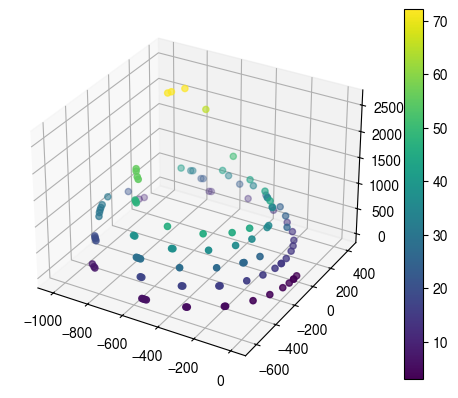

In [ ]:
multi_hits = tracker_hits[tracker_hits.particle_id == 34089]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(multi_hits.x, multi_hits.y, multi_hits.z, c=multi_hits.time, cmap="viridis")
plt.colorbar(scatter)

## Testing parquet outputs

In [150]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import awkward as ak

def load_all_particles_parquet(parquet_path, event_id=None):
    """
    Load particles data from Parquet file using awkward arrays for fast exploding.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data (flat format with one row per particle)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        # Filter to specific event
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding by examining first non-event_id column
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    # If it's not a list, data is already flat
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward array for fast exploding
    # Convert to awkward array - use ak.from_iter for nested Python lists
    ak_dict = {}
    
    # Convert each column to awkward array
    for col in df.columns:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            # For nested columns, use tolist() to convert properly
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten/explode all nested lists
    flat_dict = {}
    
    # For event_id, we need to repeat it based on the length of the nested arrays
    list_lens = ak.num(ak_dict[non_event_cols[0]])
    flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_event_cols[0]])[0])
    
    # For list columns, just flatten them
    for col in non_event_cols:
        flat_dict[col] = ak.flatten(ak_dict[col])
    
    # Convert back to pandas
    result = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    return result


def load_all_digihits_parquet(parquet_path, event_id=None):
    """
    Load digihits data from Parquet file using awkward arrays.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data (flat format with one row per hit)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward for fast exploding
    ak_dict = {}
    for col in df.columns:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten
    flat_dict = {}
    list_lens = ak.num(ak_dict[non_event_cols[0]])
    flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_event_cols[0]])[0])
    
    for col in non_event_cols:
        flat_dict[col] = ak.flatten(ak_dict[col])
    
    result = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    return result


def load_all_tracks_parquet(parquet_path, event_id=None):
    """
    Load tracks data from Parquet file using awkward arrays.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame(), None
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame(), None
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df, None
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    # If already flat
    if not isinstance(first_val, (list, np.ndarray)):
        if 'hit_ids' in df.columns:
            hits_df = df[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df, None
    
    # Use awkward for fast exploding
    has_hit_ids = 'hit_ids' in df.columns
    
    # Separate hit_ids from other columns
    track_cols = [c for c in non_event_cols if c != 'hit_ids']
    
    # Convert to awkward arrays
    ak_dict = {}
    for col in ['event_id'] + track_cols:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten track data
    flat_dict = {}
    if track_cols:
        list_lens = ak.num(ak_dict[track_cols[0]])
        flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[track_cols[0]])[0])
        
        for col in track_cols:
            flat_dict[col] = ak.flatten(ak_dict[col])
    
    tracks_df = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    
    # Handle hit_ids separately if present
    hits_df = None
    if has_hit_ids and 'track_id' in tracks_df.columns:
        # hit_ids is a list of lists - need to keep as lists in the output
        ak_hit_ids = ak.Array(df['hit_ids'].tolist())
        
        # Get track_id and event_id (already flattened)
        flat_hit_dict = {
            'event_id': flat_dict['event_id'],
            'track_id': flat_dict['track_id'],
            'hit_ids': ak.flatten(ak_hit_ids)  # Flatten outer list, keep inner lists
        }
        
        # Convert to pandas, but keep hit_ids as lists
        hits_df = pd.DataFrame({
            'event_id': ak.to_numpy(flat_hit_dict['event_id']),
            'track_id': ak.to_numpy(flat_hit_dict['track_id']),
            'hit_ids': ak.to_list(flat_hit_dict['hit_ids'])  # Keep as Python lists
        })
    
    return tracks_df, hits_df


def load_all_calohits_parquet(parquet_path, event_id=None):
    """
    Load calorimeter hits data from Parquet file using awkward arrays.
    
    Calorimeter data has nested contribution lists (particle IDs, energies, times)
    that are kept as lists in the output, representing multiple particle contributions
    to each cell.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with calorimeter hits (flat format with one row per cell, 
        with nested contribution lists preserved)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    # Identify contribution columns (nested lists that should be preserved)
    contrib_cols = [c for c in df.columns if c.startswith('contrib_')]
    
    # Get first non-contribution column to check if data needs exploding
    non_contrib_cols = [c for c in non_event_cols if c not in contrib_cols]
    if not non_contrib_cols:
        return df
    
    first_val = df[non_contrib_cols[0]].iloc[0]
    
    # If it's not a list, data is already flat
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward for fast exploding
    # Separate scalar columns from contribution columns
    scalar_cols = [c for c in df.columns if c not in contrib_cols]
    
    # Convert scalar columns to awkward arrays
    ak_dict = {}
    for col in scalar_cols:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten scalar columns
    flat_dict = {}
    if non_contrib_cols:
        list_lens = ak.num(ak_dict[non_contrib_cols[0]])
        flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_contrib_cols[0]])[0])
        
        for col in non_contrib_cols:
            flat_dict[col] = ak.flatten(ak_dict[col])
    
    # Handle contribution columns separately - flatten outer list but keep inner lists
    for col in contrib_cols:
        if col in df.columns:
            ak_col = ak.Array(df[col].tolist())
            flat_dict[col] = ak.to_list(ak.flatten(ak_col))
    
    # Convert back to pandas
    result = pd.DataFrame(flat_dict)
    return result


In [151]:
# Update file paths to point to parquet files
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v1/parquet/truth/particles/hard_scatter.ttbar.v1.truth.particles.events0-9.parquet"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracker_hits/hard_scatter.ttbar.v1.reco.tracker_hits.events0-9.parquet"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracks/hard_scatter.ttbar.v1.reco.tracks.events0-9.parquet"
calohits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.events0-9.parquet"

In [152]:
# Test loading a single event from parquet with improved functions
global_event_id = 1
particles_df = load_all_particles_parquet(particles_file, event_id=global_event_id)
digihits_df = load_all_digihits_parquet(digihits_file, event_id=global_event_id)
tracks_df, track_hits_df = load_all_tracks_parquet(tracks_file, event_id=global_event_id)
calohits_df = load_all_calohits_parquet(calohits_file, event_id=global_event_id)

print(f"Loaded event {global_event_id}:")
print(f"  Particles: {len(particles_df)} rows")
print(f"  Digihits: {len(digihits_df)} rows")
print(f"  Tracks: {len(tracks_df)} rows")
print(f"  Calohits: {len(calohits_df)} rows")
if track_hits_df is not None:
    print(f"  Track hit associations: {len(track_hits_df)} rows")

print("\nParticles sample:")
print(particles_df.head() if not particles_df.empty else "Empty")

print("\nDigihits sample:")
print(digihits_df.head() if not digihits_df.empty else "Empty")

print("\nTracks sample:")
print(tracks_df.head() if not tracks_df.empty else "Empty")

Loaded event 1:
  Particles: 283 rows
  Digihits: 1725 rows
  Tracks: 28 rows
  Calohits: 15890 rows
  Track hit associations: 28 rows

Particles sample:
   event_id  particle_id  pdg_id      mass       energy  charge        vx  \
0         1           10     211  0.139570  1935.443866     1.0 -0.023709   
1         1           11    -211  0.139570    28.814048    -1.0 -0.023709   
2         1           12     211  0.139570   720.878096     1.0 -0.023709   
3         1           13     313  0.910694   280.241581     0.0 -0.023709   
4         1           79     221  0.547850  1013.028273     0.0 -0.023709   

         vy         vz      time        px        py           pz  \
0  0.010315  106.12365  4.075578 -0.005252  0.206870  1935.443848   
1  0.010315  106.12365  4.075578  0.212135 -0.101696    28.812750   
2  0.010315  106.12365  4.075578 -0.045457 -0.136436   720.878052   
3  0.010315  106.12365  4.075578 -0.161426  0.031262   280.240051   
4  0.010315  106.12365  4.075578  0.94

In [153]:
particles_df

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,num_tracker_hits,num_calo_hits,vertex_primary,parent_id
0,1,10,211,0.139570,1935.443866,1.0,-0.023709,0.010315,106.123650,4.075578,-0.005252,0.206870,1935.443848,0,0,1,3.0
1,1,11,-211,0.139570,28.814048,-1.0,-0.023709,0.010315,106.123650,4.075578,0.212135,-0.101696,28.812750,0,0,1,3.0
2,1,12,211,0.139570,720.878096,1.0,-0.023709,0.010315,106.123650,4.075578,-0.045457,-0.136436,720.878052,0,0,1,3.0
3,1,13,313,0.910694,280.241581,0.0,-0.023709,0.010315,106.123650,4.075578,-0.161426,0.031262,280.240051,0,0,1,3.0
4,1,79,221,0.547850,1013.028273,0.0,-0.023709,0.010315,106.123650,4.075578,0.947756,4.233927,-1013.018860,0,0,1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,1,2594,11,0.000511,0.404189,-1.0,69.379494,-6.625940,-339.454803,5.579952,0.062982,-0.003172,-0.399239,6,6,1,2583.0
279,1,2596,11,0.000511,2.226355,-1.0,175.592941,-110.691734,-1771.551636,10.376991,0.207933,-0.130599,-2.212773,3,273,1,167.0
280,1,2607,11,0.000511,0.840776,-1.0,176.572449,-111.312431,-1782.186768,10.412677,0.077295,-0.048878,-0.835788,3,1,1,2598.0
281,1,2631,-11,0.000511,0.009594,1.0,-295.340271,-123.454201,-3226.103271,15.241867,-0.000779,-0.000047,-0.009548,6,1,1,2625.0


In [154]:
digihits_df

,event_id,x,y,z,time,particle_id,true_x,true_y,true_z,volume_id,layer_id,surface_id,cell_id,detector
0,1,62.924999,7.075000,-1515.599976,9.523190,139,62.932228,7.058239,-1515.599976,16,4,1,16986595655783,1
1,1,62.991711,7.069336,-1516.800049,9.527220,139,62.978283,7.067547,-1516.800049,16,4,2,811748820071,1
2,1,18.784645,-39.871773,-1516.800049,9.525582,138,18.778696,-39.849426,-1516.800049,16,4,12,16917876198503,1
3,1,18.754856,-39.834366,-1515.599976,9.521553,138,18.767567,-39.819340,-1515.599976,16,4,14,313532633191,1
4,1,82.660782,-68.129738,-1516.800049,10.002185,1346,82.653900,-68.108162,-1516.800049,16,4,15,16707422803047,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720,1,726.035828,381.151642,2590.500000,12.893661,180,662.905090,346.376953,2590.500000,30,10,70,16647294304334,5
1721,1,-620.881348,-770.861023,2604.500000,36.677681,1304,-599.901550,-744.604858,2604.549561,30,10,147,665720058190,5
1722,1,-783.438965,247.184326,2995.500000,16.332100,2461,-740.571777,236.626617,2995.510010,30,12,31,16557099016286,5
1723,1,741.127075,355.885712,2974.500000,14.256558,180,777.131531,370.002380,2974.500000,30,12,47,16299400900702,5


In [155]:
tracks_df

,event_id,majority_particle_id,d0,z0,phi,theta,qop,track_id
0,1,322,-0.056372,106.112633,1.643450,2.003878,0.739574,28
1,1,295,0.026130,106.107903,1.151704,2.426238,0.063997,26
2,1,311,0.007568,106.130936,1.184166,2.392341,0.144818,25
3,1,293,0.006198,106.099228,1.187212,2.401597,-0.188204,24
4,1,312,0.039622,106.136642,1.195273,2.459596,-0.056827,23
5,1,180,0.012413,106.025429,0.723405,0.295152,0.205205,20
6,1,103,0.020846,106.349869,0.679420,0.124362,0.089558,19
7,1,277,0.024353,106.087814,0.466671,1.729789,-0.217020,17
8,1,272,-0.013561,106.147293,0.335296,1.779744,-0.914151,14
9,1,258,0.026705,106.128098,0.367831,1.804979,0.115466,13


In [156]:
track_hits_df

,event_id,track_id,hit_ids
0,1,28,"[174, 346, 358, 478, 743, 874, 871, 963, 1040,..."
1,1,26,"[166, 335, 456, 352, 467, 821, 859, 956, 1032,..."
2,1,25,"[163, 332, 350, 466, 469, 820, 858, 954, 1029,..."
3,1,24,"[164, 333, 351, 470, 826, 866, 961, 960, 1038,..."
4,1,23,"[168, 338, 354, 472, 828, 868, 959, 1035, 1360..."
5,1,20,"[160, 314, 321, 452, 530, 812, 1107, 1114, 112..."
6,1,19,"[153, 528, 526, 536, 532, 541, 538, 543, 548, ..."
7,1,17,"[124, 283, 318, 410, 513, 786, 928, 916, 1005,..."
8,1,14,"[127, 286, 402, 503, 780, 920, 1012, 1024, 150..."
9,1,13,"[125, 285, 403, 498, 505, 767, 908, 991, 1081,..."


In [157]:
calohits_df

,event_id,detector,cell_id,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times
0,1,ECalBarrelCollection,18430137110230026256,0.000448,-545.237732,1129.743164,-300.899994,"[361, 383]","[0.00026952987536787987, 0.00017890887102112174]","[8.479477882385254, 8.47303581237793]"
1,1,ECalBarrelCollection,18430137110230091792,0.000504,-547.170288,1134.408691,-300.899994,[383],[0.0005035966169089079],[8.490617752075195]
2,1,ECalBarrelCollection,18430137110230157328,0.001057,-549.102844,1139.074341,-300.899994,[383],[0.0010573721956461668],[8.510907173156738]
3,1,ECalBarrelCollection,18429855635253512208,0.000455,-551.035400,1143.739868,-306.000000,[383],[0.00045471027260646224],[8.527135848999023]
4,1,ECalBarrelCollection,18429855635253577744,0.000231,-552.967957,1148.405518,-306.000000,[383],[0.00023131832131184638],[8.54515552520752]
...,...,...,...,...,...,...,...,...,...,...
15885,1,HCalEndcapCollection,18432670333478906388,0.003096,311.935272,-194.151352,-5432.500000,"[2670, 2671, 2675]","[0.0013684846926480532, 0.0009482990717515349,...","[22.604480743408203, 22.604839324951172, 22.60..."
15886,1,HCalEndcapCollection,18432951812750584340,0.000562,328.171143,-233.348236,-5432.500000,[2671],[0.0005615330301225185],[22.65459632873535]
15887,1,HCalEndcapCollection,18432951808455617044,0.005563,339.651642,-205.631851,-5432.500000,"[2671, 2670, 2676, 2675, 2672]","[0.0017110318876802921, 0.0009640532662160695,...","[22.66902732849121, 22.606521606445312, 22.607..."
15888,1,HCalEndcapCollection,18432951804160670228,0.000582,-374.093170,-122.482697,-5432.500000,[2673],[0.0005817414494231343],[24.87398338317871]


## Summary: Parquet Structure

**Writing side** (using PyArrow groupby):
- Creates proper Arrow list arrays (efficient)
- Schema: `event_id: int64, particle_id: list<int64>, px: list<double>, ...`

**Reading side** (using awkward arrays):
1. Read parquet → pandas (columns have list objects)
2. Convert to awkward with `.tolist()` (handles nested lists)
3. Use `ak.flatten()` to explode lists
4. Use `ak.broadcast_arrays()` to repeat event_id
5. Convert back to pandas with flat structure

This is **straightforward and efficient** - awkward is designed exactly for this pattern!

## Validation Checks

In [56]:
# Add number of hits of particle to tracks_df
tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
tracks_df["hit_ids"] = track_hits_df.hit_ids

def get_num_shared_hits(track_row):
    track_hit_ids = track_row.hit_ids
    particle_hit_ids = digihits_df[digihits_df.particle_id == track_row.majority_particle_id].index.tolist()
    return len(set(track_hit_ids) & set(particle_hit_ids))

tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)

In [57]:
tracks_df["efficiency"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]

In [58]:
print(f"Efficiency: {tracks_df.efficiency.mean()}, Purity: {tracks_df.purity.mean()}")

Efficiency: 0.9628205128205127, Purity: 0.9955357142857143


In [60]:
for global_event_id in range(0, 10):
    particles_df = load_all_particles_parquet(particles_file, event_id = global_event_id)
    digihits_df = load_all_digihits_parquet(digihits_file, event_id = global_event_id)
    tracks_df, track_hits_df = load_all_tracks_parquet(tracks_file, event_id = global_event_id)
    tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
    tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
    tracks_df["hit_ids"] = track_hits_df.hit_ids
    tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)
    tracks_df["completeness"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
    tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]
    print(f"Completeness: {tracks_df.completeness.mean()}, Purity: {tracks_df.purity.mean()}")


Completeness: 0.9628205128205127, Purity: 0.9955357142857143
Completeness: 0.9856178908810488, Purity: 1.0
Completeness: 0.9608598187158561, Purity: 0.9860915400389085
Completeness: 0.9840563120454425, Purity: 0.9883195307108351
Completeness: 0.9608598187158561, Purity: 0.9860915400389085
Completeness: 0.9840563120454425, Purity: 0.9883195307108351
Completeness: 0.979889622515673, Purity: 0.9947845804988662
Completeness: 0.9835893957726538, Purity: 0.9913129605437297
Completeness: 0.979889622515673, Purity: 0.9947845804988662
Completeness: 0.9835893957726538, Purity: 0.9913129605437297
Completeness: 0.9630447330447331, Purity: 0.9917171717171719
Completeness: 0.9855819055545457, Purity: 0.9881335718545021
Completeness: 0.9630447330447331, Purity: 0.9917171717171719
Completeness: 0.9855819055545457, Purity: 0.9881335718545021
Completeness: 0.9595112295112297, Purity: 0.99347442680776
Completeness: 0.9944132978635241, Purity: 0.9883558748943364
Completeness: 0.9595112295112297, Purity: 0

Text(0.5, 1.0, 'Track 0: Track hits vs True particle hits, track ID: 58')

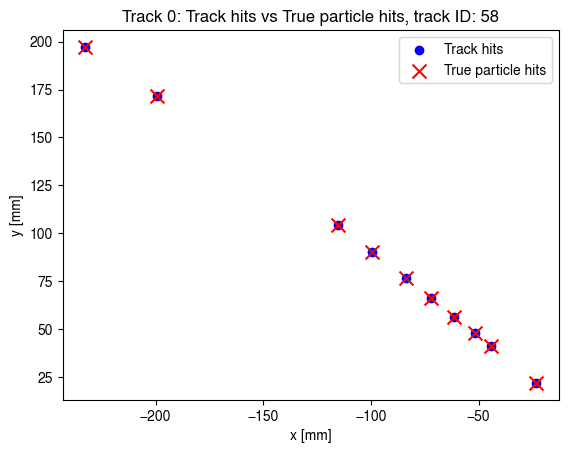

In [61]:
track_index = 0
track_hit_ids = track_hits_df.iloc[track_index].hit_ids

plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color="b", label="Track hits")

# Get the majority particle id for the track
track_majority_particle_id = tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color="red", s=100, label="True particle hits")

# Add legend
plt.legend()
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Track {track_index}: Track hits vs True particle hits, track ID: {tracks_df.track_id.iloc[track_index]}")

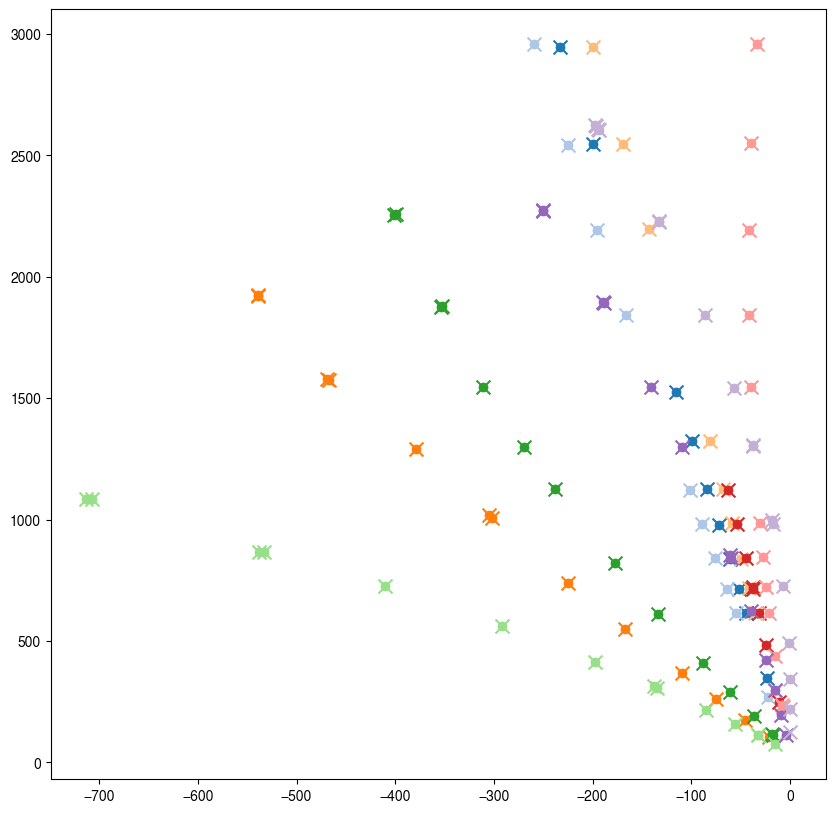

In [62]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.z.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.z.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

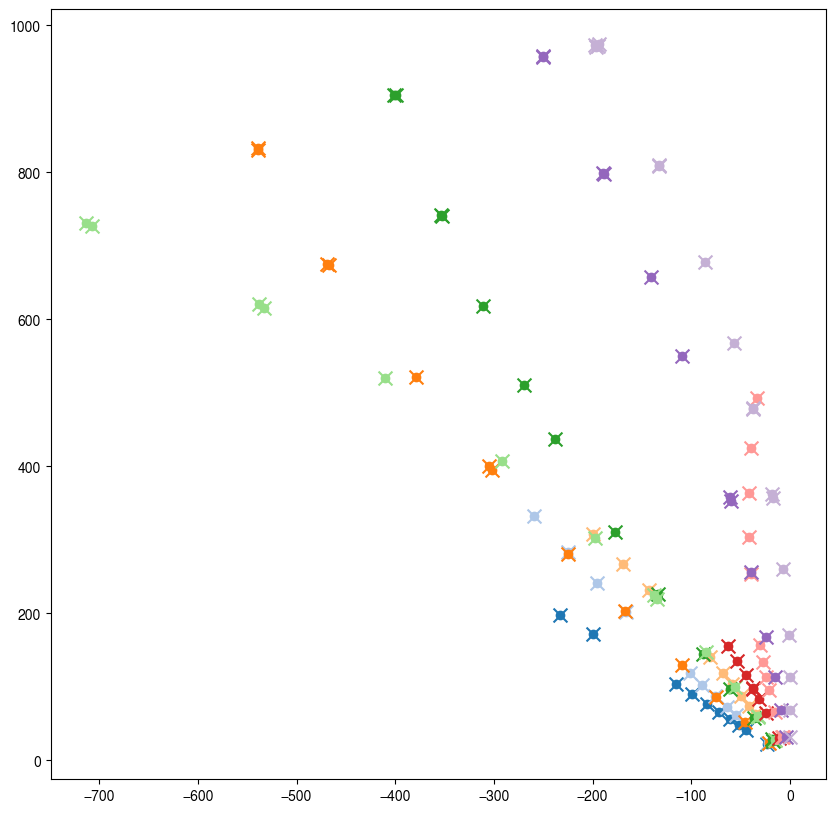

In [63]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

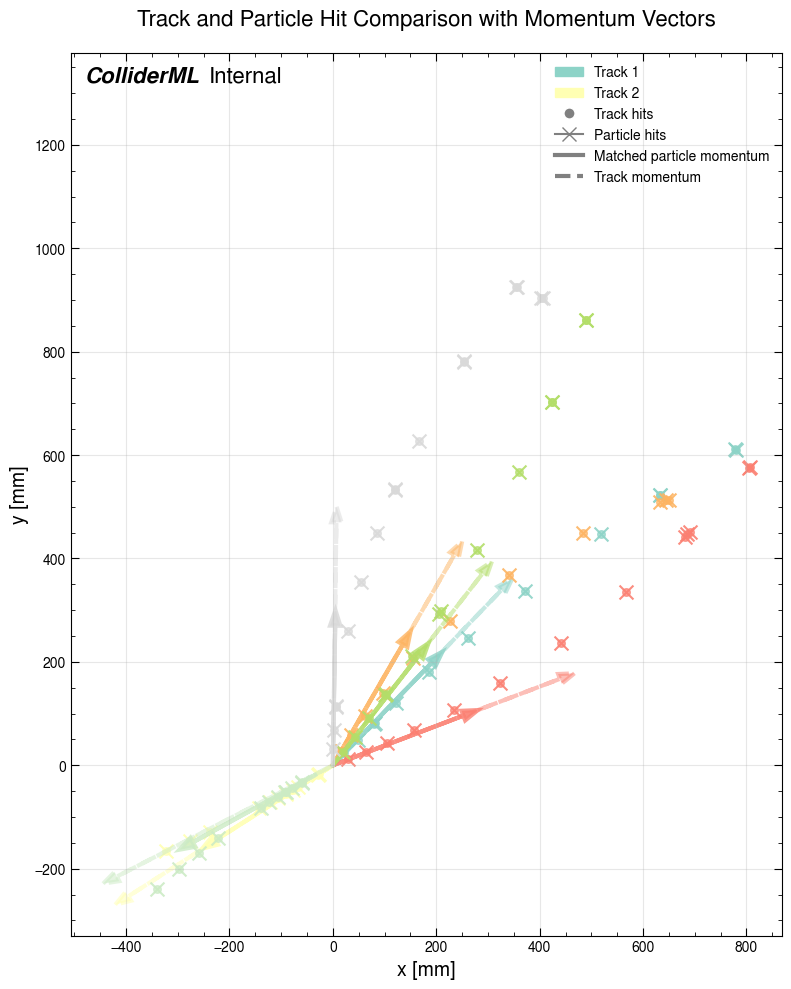

In [64]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(tracks_df), size=min(num_tracks_to_sample, len(tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = particles_df[particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()
